box plot

Saved: D:\BIOvisdata\SSGAT\Groundtruth\boxplot_grid_all_topics_3D.png


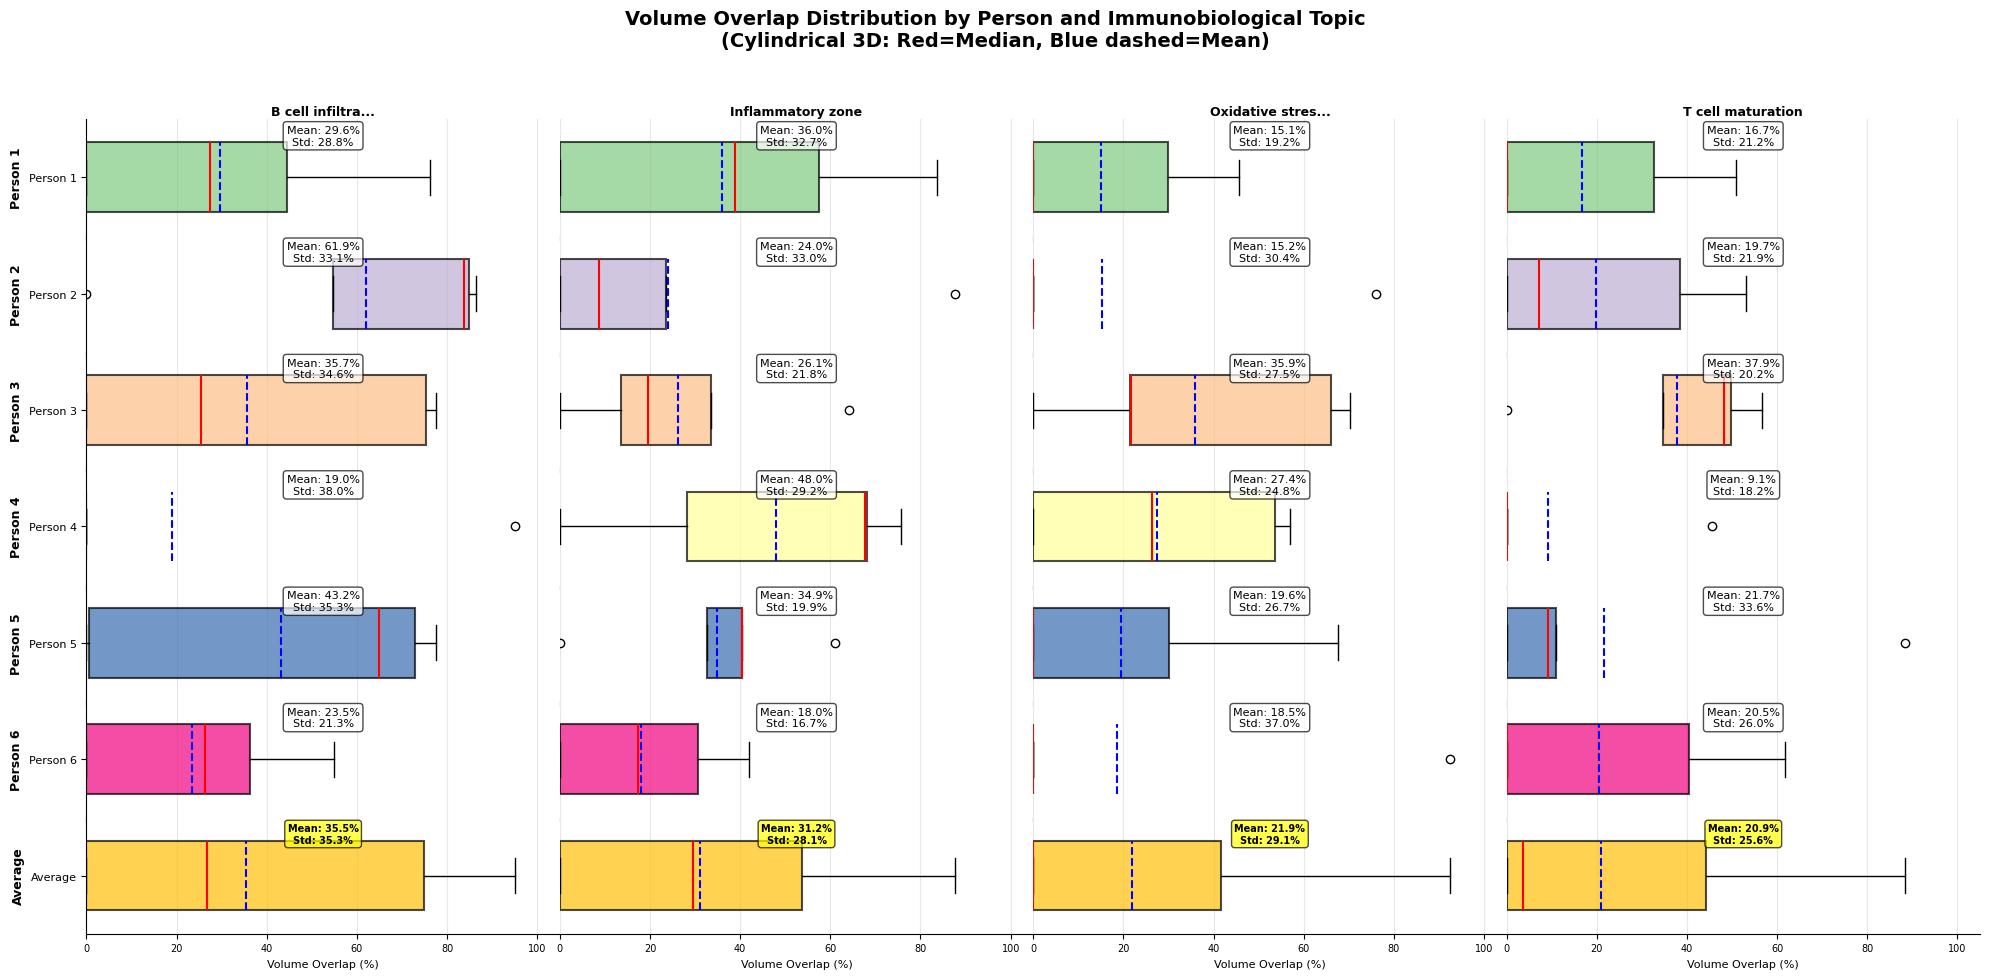

Saved: D:\BIOvisdata\SSGAT\Groundtruth\heatmap_volume_overlap_3D.png


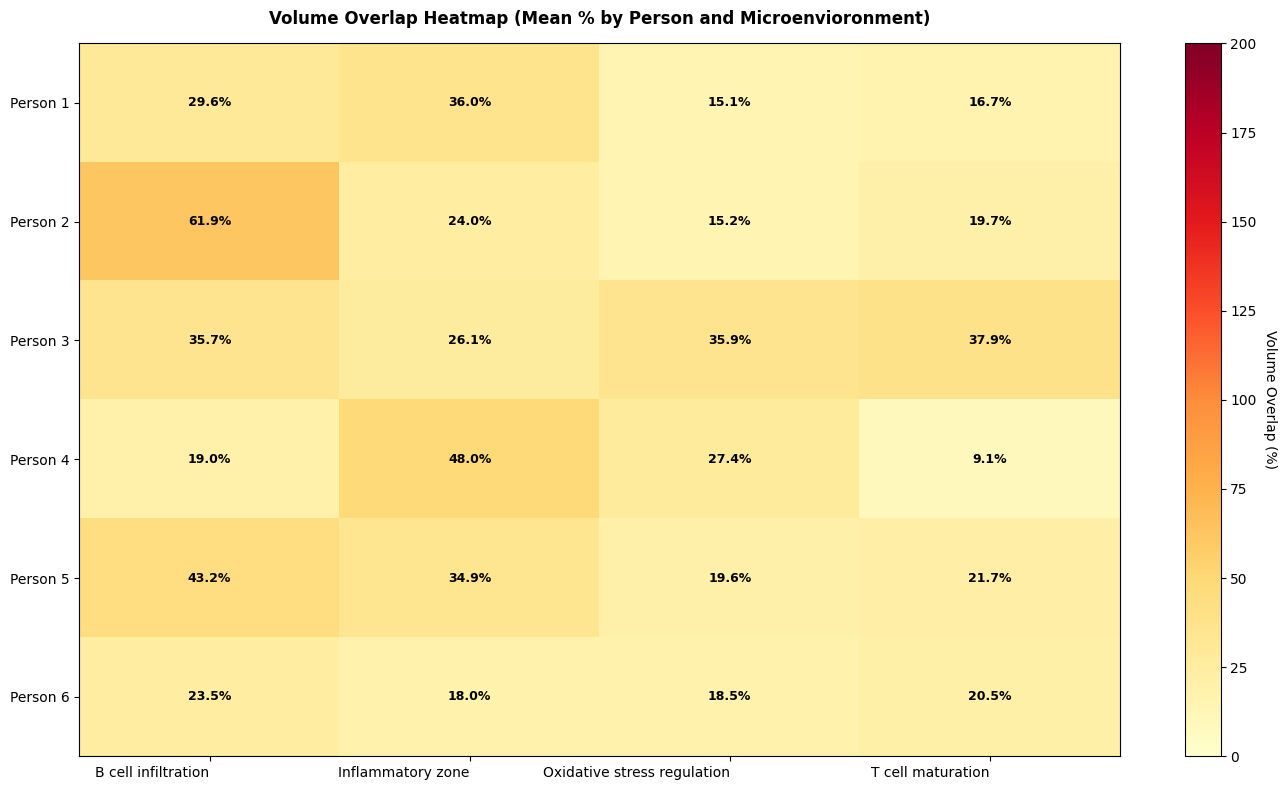

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math
import warnings
warnings.filterwarnings('ignore')

base_dir = Path(r"D:\BIOvisdata\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

cylinder_radius, cylinder_height = 400, 100
z_tolerance = 50

def circle_overlap(c1, c2, r):
    d = math.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)
    if d >= 2*r: return 0.0
    if d == 0: return 100.0
    try:
        area = 2*r**2*math.acos(d/(2*r)) - (d/2)*math.sqrt(4*r**2-d**2)
        return min(100.0, (area/(math.pi*r**2))*100)
    except: return 100.0 if d < 2*r else 0.0

def z_overlap(z1, z2, h, z_tol):
    dz = abs(z1 - z2)
    if dz <= z_tol:
        return 100.0
    excess_diff = dz - z_tol
    overlap_percent = max(0.0, 100.0 - (excess_diff / h) * 100)
    return overlap_percent

def volume_overlap(c1, z1, c2, z2, r, h, z_tol):
    xy_overlap = circle_overlap(c1, c2, r) / 100.0
    z_overlap_pct = z_overlap(z1, z2, h, z_tol) / 100.0
    return min(100.0, xy_overlap * z_overlap_pct * 100.0)

def calc_overlaps(gat_data, person_data, r, h, z_tol):
    if len(gat_data) == 0 or len(person_data) == 0: return []
    gat = gat_data[['x', 'y', 'z']].values
    person = person_data[['x', 'y', 'z']].values
    rows, cols = linear_sum_assignment(cdist(gat, person))
    return [volume_overlap((gat[i][0], gat[i][1]), gat[i][2], (person[j][0], person[j][1]), person[j][2], r, h, z_tol)
            for i, j in zip(rows, cols)]

# Process each CSV file
results = {}
all_overlaps = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    results[sheet_name] = {}
    
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            continue
        
        overlaps = calc_overlaps(gat_data, person_data, cylinder_radius, cylinder_height, z_tolerance)
        
        if len(overlaps) > 0:
            results[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': np.mean(overlaps),
                'std': np.std(overlaps),
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps[person_name].extend(overlaps)


person_names = [f'Person {i}' for i in range(1, 7)]
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#f0027f']
topics_list = list(results.keys()) if len(results) > 0 else []

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(7, 4, hspace=0.0, wspace=0.0)

for col_idx, sheet_name in enumerate(topics_list):
    all_topic_overlaps = []
    
    for row_idx, person_name in enumerate(person_names):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        if person_name in results[sheet_name]:
            overlaps = results[sheet_name][person_name]['overlaps']
            if len(overlaps) > 0:
                all_topic_overlaps.extend(overlaps)
                bp = ax.boxplot([overlaps], tick_labels=[person_name], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
                bp['boxes'][0].set_facecolor(person_colors[row_idx])
                bp['boxes'][0].set_alpha(0.7)
                bp['boxes'][0].set_edgecolor('black')
                bp['boxes'][0].set_linewidth(1.5)
                
                stats = results[sheet_name][person_name]
                stats_text = f"Mean: {stats['mean']:.1f}%\nStd: {stats['std']:.1f}%"
                ax.text(0.5, 0.95, stats_text, transform=ax.transAxes,
                       ha='center', va='top', fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            else:
                bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
                bp['boxes'][0].set_facecolor('lightgray')
                bp['boxes'][0].set_alpha(0.3)
        else:
            bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
            bp['boxes'][0].set_facecolor('lightgray')
            bp['boxes'][0].set_alpha(0.3)
        
        ax.set_xlim(0, 105)
        ax.grid(True, alpha=0.3, axis='x')
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx < 6:
            ax.spines['bottom'].set_visible(False)
        if col_idx > 0:
            ax.spines['left'].set_visible(False)
        
        if col_idx == 0:
            ax.set_ylabel(person_name, fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
        
        if row_idx == 6:
            ax.set_xlabel('Volume Overlap (%)', fontsize=8)
        else:
            ax.set_xticklabels([])
        
        if row_idx == 0:
            short_name = sheet_name.replace('_', ' ').replace('-', ' ')
            if len(short_name) > 18:
                short_name = short_name[:15] + '...'
            ax.set_title(short_name, fontsize=9, fontweight='bold', pad=3)
    
    ax_avg = fig.add_subplot(gs[6, col_idx])
    if len(all_topic_overlaps) > 0:
        bp_avg = ax_avg.boxplot([all_topic_overlaps], tick_labels=['Average'], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
        bp_avg['boxes'][0].set_facecolor('#FFC107')
        bp_avg['boxes'][0].set_alpha(0.7)
        bp_avg['boxes'][0].set_edgecolor('black')
        bp_avg['boxes'][0].set_linewidth(1.5)
        
        stats_text = f"Mean: {np.mean(all_topic_overlaps):.1f}%\nStd: {np.std(all_topic_overlaps):.1f}%"
        ax_avg.text(0.5, 0.95, stats_text, transform=ax_avg.transAxes,
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    else:
        bp_avg = ax_avg.boxplot([[]], tick_labels=['Average'], patch_artist=True, vert=False, widths=0.6)
        bp_avg['boxes'][0].set_facecolor('lightgray')
        bp_avg['boxes'][0].set_alpha(0.3)
    
    ax_avg.set_xlim(0, 105)
    ax_avg.grid(True, alpha=0.3, axis='x')
    ax_avg.tick_params(axis='y', labelsize=8)
    ax_avg.tick_params(axis='x', labelsize=7)
    ax_avg.set_xlabel('Volume Overlap (%)', fontsize=8)
    ax_avg.spines['top'].set_visible(False)
    ax_avg.spines['right'].set_visible(False)
    if col_idx > 0:
        ax_avg.spines['left'].set_visible(False)
    
    if col_idx == 0:
        ax_avg.set_ylabel('Average', fontsize=9, fontweight='bold')
    else:
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])

fig.suptitle('Volume Overlap Distribution by Person and Immunobiological Topic\n(Cylindrical 3D: Red=Median, Blue dashed=Mean)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
output_path = base_dir / 'boxplot_grid_all_topics_3D.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

# Create heatmap
fig2, ax2 = plt.subplots(figsize=(14, 8))
heatmap_data = []
heatmap_rows = []
heatmap_cols = topics_list

for person_name in person_names:
    row_data = []
    for sheet_name in topics_list:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['overlaps']) > 0:
            row_data.append(results[sheet_name][person_name]['mean'])
        else:
            row_data.append(np.nan)
    if any(not np.isnan(x) for x in row_data):
        heatmap_data.append(row_data)
        heatmap_rows.append(person_name)

if len(heatmap_data) > 0:
    heatmap_array = np.array(heatmap_data)
    im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    
    ax2.set_xticks(np.arange(len(heatmap_cols)))
    ax2.set_yticks(np.arange(len(heatmap_rows)))
    ax2.set_xticklabels([name.replace('_', ' ').replace('-', ' ') for name in heatmap_cols], rotation=45, ha='right')
    ax2.set_yticklabels(heatmap_rows)
    
    for i in range(len(heatmap_rows)):
        for j in range(len(heatmap_cols)):
            if not np.isnan(heatmap_array[i, j]):
                text = ax2.text(j, i, f'{heatmap_array[i, j]:.1f}%',
                              ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax2.set_title('Volume Overlap Heatmap (Mean % by Person and Microenvioronment)', fontsize=12, fontweight='bold', pad=14)
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Volume Overlap (%)', rotation=0, labelpad=15)
    
    plt.tight_layout()
    heatmap_path = base_dir / 'heatmap_volume_overlap_3D.png'
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {heatmap_path}")
    plt.show()


BArchart

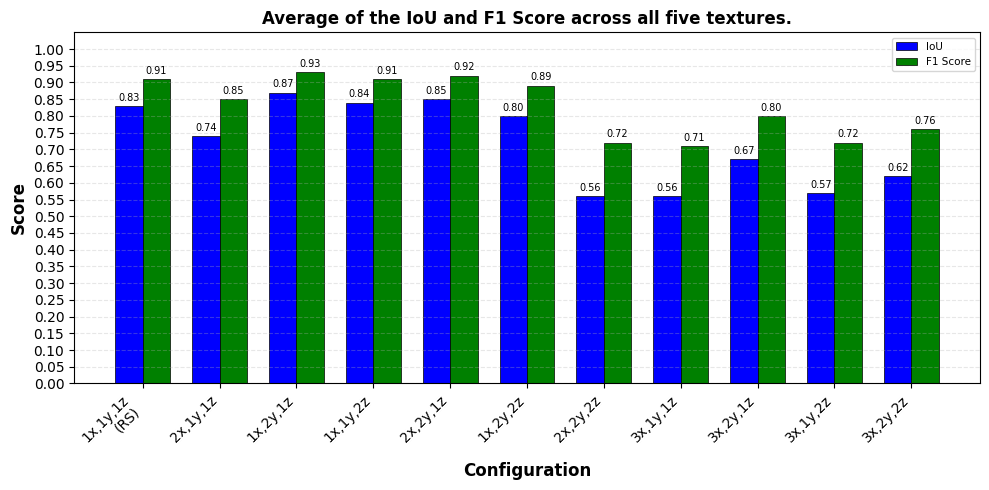

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Table 1
configurations = [
    '1x,1y,1z\n(RS)',
    '2x,1y,1z',
    '1x,2y,1z',
    '1x,1y,2z',
    '2x,2y,1z',
    '1x,2y,2z',
    '2x,2y,2z',
    '3x,1y,1z',
    '3x,2y,1z',
    '3x,1y,2z',
    '3x,2y,2z'
]

IoU_scores = [
    0.83, 0.74, 0.87, 0.84, 0.85, 0.80, 0.56,
    0.56, 0.67, 0.57, 0.62]

f1_scores = [
    0.91, 0.85, 0.93, 0.91, 0.92, 0.89, 0.72,
    0.71, 0.80, 0.72, 0.76]

# Create bar chart with grouped bars
x = np.arange(len(configurations)) * 0.7  # Closer x steps for compact figure
width = 0.25  # Thinner bars

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, IoU_scores, width, label='IoU', 
               color='blue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', 
               color='green', edgecolor='black', linewidth=0.5)

# Customize the chart
ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Average of the IoU and F1 Score across all five textures.', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configurations, rotation=45, ha='right', fontsize=10)
ax.set_yticks(np.arange(0.0, 1.05, 0.05))
ax.set_yticklabels([f'{i:.2f}' for i in np.arange(0.0, 1.05, 0.05)], fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=7.5)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=7)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

Scale	Linear F1	Linear IoU	Olympic F1	Olympic IoU	Sinusoid F1	Sinusoid IoU	Colonies F1	Colonies IoU	Oval F1	Oval IoU	Avg	Avg
1x,1y,1z	0.951	0.906	0.932	0.873	0.911	0.837	0.893	0.807	0.849	0.738	0.907	0.832
2x,1y,1z	0.837	0.719	0.877	0.782	0.899	0.816	0.844	0.730	0.784	0.644	0.848	0.738
1x,2y,1z	0.829	0.708	0.897	0.813	0.810	0.681	0.846	0.733	0.834	0.715	0.843	0.730
1x,1y,2z	0.841	0.726	0.909	0.833	0.861	0.755	0.851	0.740	0.880	0.785	0.868	0.768
2x,2y,1z	0.814	0.686	0.804	0.672	0.824	0.701	0.805	0.673	0.855	0.747	0.820	0.696
1x,2y,2z	0.836	0.719	0.830	0.710	0.807	0.677	0.845	0.731	0.867	0.765	0.837	0.720
2x,2y,2z	0.833	0.714	0.819	0.694	0.789	0.651	0.834	0.716	0.838	0.721	0.823	0.699
3x,1y,1z	0.600	0.429	0.676	0.510	0.874	0.775	0.673	0.507	0.677	0.512	0.700	0.547
3x,2y,1z	0.710	0.551	0.768	0.623	0.787	0.649	0.746	0.595	0.673	0.542	0.737	0.592
3x,1y,2z	0.708	0.548	0.740	0.588	0.793	0.656	0.707	0.547	0.626	0.582	0.715	0.584
3x,2y,2z	0.719	0.561	0.754	0.605	0.758	0.610	0.754	0.605	0.648	0.610	0.726	0.598


F1 table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.951,0.932,0.911,0.893,0.849
"2x,1y,1z",0.837,0.877,0.899,0.844,0.784
"1x,2y,1z",0.829,0.897,0.810,0.846,0.834
"1x,1y,2z",0.841,0.909,0.861,0.851,0.880
"2x,2y,1z",0.814,0.804,0.824,0.805,0.855
"1x,2y,2z",0.836,0.830,0.807,0.845,0.867
"2x,2y,2z",0.833,0.819,0.789,0.834,0.838
"3x,1y,1z",0.600,0.676,0.874,0.673,0.677
"3x,2y,1z",0.710,0.768,0.787,0.746,0.673
"3x,1y,2z",0.708,0.740,0.793,0.707,0.626



IoU table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.906,0.873,0.837,0.807,0.738
"2x,1y,1z",0.719,0.782,0.816,0.730,0.644
"1x,2y,1z",0.708,0.813,0.681,0.733,0.715
"1x,1y,2z",0.726,0.833,0.755,0.740,0.785
"2x,2y,1z",0.686,0.672,0.701,0.673,0.747
"1x,2y,2z",0.719,0.710,0.677,0.731,0.765
"2x,2y,2z",0.714,0.694,0.651,0.716,0.721
"3x,1y,1z",0.429,0.510,0.775,0.507,0.512
"3x,2y,1z",0.551,0.623,0.649,0.595,0.542
"3x,1y,2z",0.548,0.588,0.656,0.547,0.582


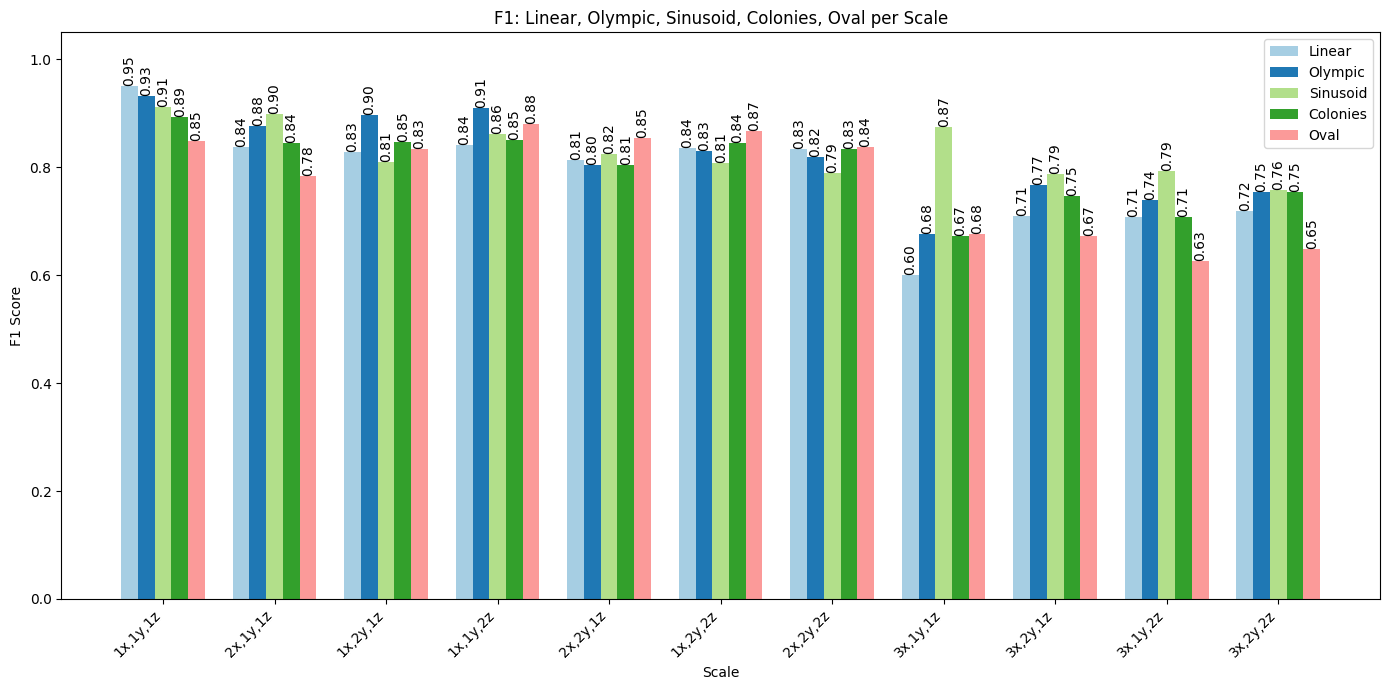

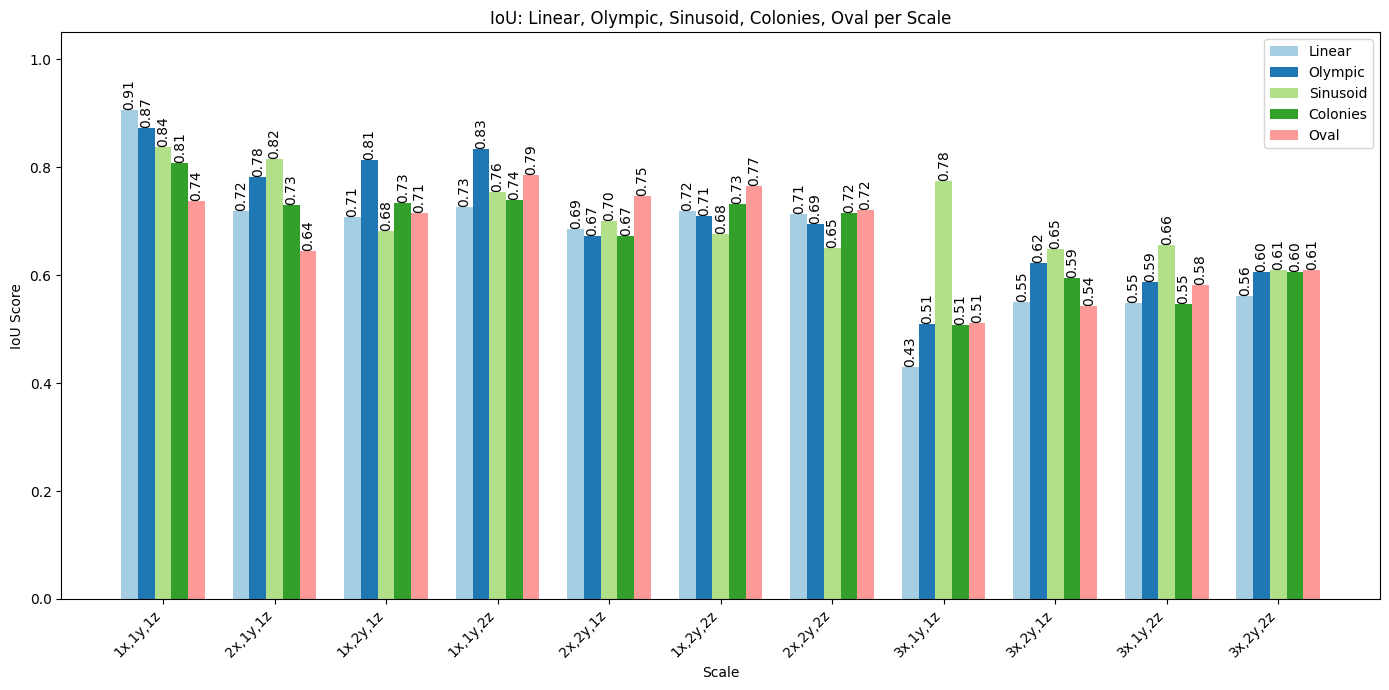

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Data (five patterns: Linear, Olympic, Sinusoid, Colonies, Oval)
data_str = """Scale	Linear F1	Linear IoU	Olympic F1	Olympic IoU	Sinusoid F1	Sinusoid IoU	Colonies F1	Colonies IoU	Oval F1	Oval IoU
1x,1y,1z	0.951	0.906	0.932	0.873	0.911	0.837	0.893	0.807	0.849	0.738
2x,1y,1z	0.837	0.719	0.877	0.782	0.899	0.816	0.844	0.730	0.784	0.644
1x,2y,1z	0.829	0.708	0.897	0.813	0.810	0.681	0.846	0.733	0.834	0.715
1x,1y,2z	0.841	0.726	0.909	0.833	0.861	0.755	0.851	0.740	0.880	0.785
2x,2y,1z	0.814	0.686	0.804	0.672	0.824	0.701	0.805	0.673	0.855	0.747
1x,2y,2z	0.836	0.719	0.830	0.710	0.807	0.677	0.845	0.731	0.867	0.765
2x,2y,2z	0.833	0.714	0.819	0.694	0.789	0.651	0.834	0.716	0.838	0.721
3x,1y,1z	0.600	0.429	0.676	0.510	0.874	0.775	0.673	0.507	0.677	0.512
3x,2y,1z	0.710	0.551	0.768	0.623	0.787	0.649	0.746	0.595	0.673	0.542
3x,1y,2z	0.708	0.548	0.740	0.588	0.793	0.656	0.707	0.547	0.626	0.582
3x,2y,2z	0.719	0.561	0.754	0.605	0.758	0.610	0.754	0.605	0.648	0.610"""

lines = data_str.strip().split("\n")
headers = lines[0].split("\t")
rows = []
for line in lines[1:]:
    parts = line.split("\t")
    row = {h: (float(v) if h != "Scale" else v) for h, v in zip(headers, parts)}
    rows.append(row)

patterns = ['Linear', 'Olympic', 'Sinusoid', 'Colonies', 'Oval']
colors = {'Linear': '#a6cee3', 'Olympic': '#1f78b4', 'Sinusoid': '#b2df8a', 'Colonies': '#33a02c', 'Oval': '#fb9a99'}
scales = [r['Scale'] for r in rows]
n_scales = len(scales)

def make_html_table(rows, patterns, metric):
    h = '<table border="1" style="border-collapse:collapse"><tr><th>Scale</th>' + ''.join(f'<th>{p}</th>' for p in patterns) + '</tr>'
    for r in rows:
        h += '<tr><td>' + r['Scale'] + '</td>' + ''.join(f'<td>{r[f"{p} {metric}"]:.3f}</td>' for p in patterns) + '</tr>'
    return h + '</table>'

print("F1 table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'F1')))
print("\nIoU table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'IoU')))

x = np.arange(n_scales)
width = 0.15

fig1, ax1 = plt.subplots(figsize=(14, 7))
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} F1'] for r in rows])
    bars = ax1.bar(x + offset, vals, width, label=p, color=colors[p])
    ax1.bar_label(bars, labels=[f'{v:.2f}' for v in vals], rotation=90, fontsize=10)
ax1.set_xlabel('Scale')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1: Linear, Olympic, Sinusoid, Colonies, Oval per Scale')
ax1.set_xticks(x)
ax1.set_xticklabels(scales, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 7))
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} IoU'] for r in rows])
    bars = ax2.bar(x + offset, vals, width, label=p, color=colors[p])
    ax2.bar_label(bars, labels=[f'{v:.2f}' for v in vals], rotation=90, fontsize=10)
ax2.set_xlabel('Scale')
ax2.set_ylabel('IoU Score')
ax2.set_title('IoU: Linear, Olympic, Sinusoid, Colonies, Oval per Scale')
ax2.set_xticks(x)
ax2.set_xticklabels(scales, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

F1 table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.951,0.932,0.911,0.893,0.849
"2x,1y,1z",0.837,0.877,0.899,0.844,0.784
"1x,2y,1z",0.829,0.897,0.810,0.846,0.834
"1x,1y,2z",0.841,0.909,0.861,0.851,0.880
"2x,2y,1z",0.814,0.804,0.824,0.805,0.855
"1x,2y,2z",0.836,0.830,0.807,0.845,0.867
"2x,2y,2z",0.833,0.819,0.789,0.834,0.838



IoU table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.906,0.873,0.837,0.807,0.738
"2x,1y,1z",0.719,0.782,0.816,0.730,0.644
"1x,2y,1z",0.708,0.813,0.681,0.733,0.715
"1x,1y,2z",0.726,0.833,0.755,0.740,0.785
"2x,2y,1z",0.686,0.672,0.701,0.673,0.747
"1x,2y,2z",0.719,0.710,0.677,0.731,0.765
"2x,2y,2z",0.714,0.694,0.651,0.716,0.721


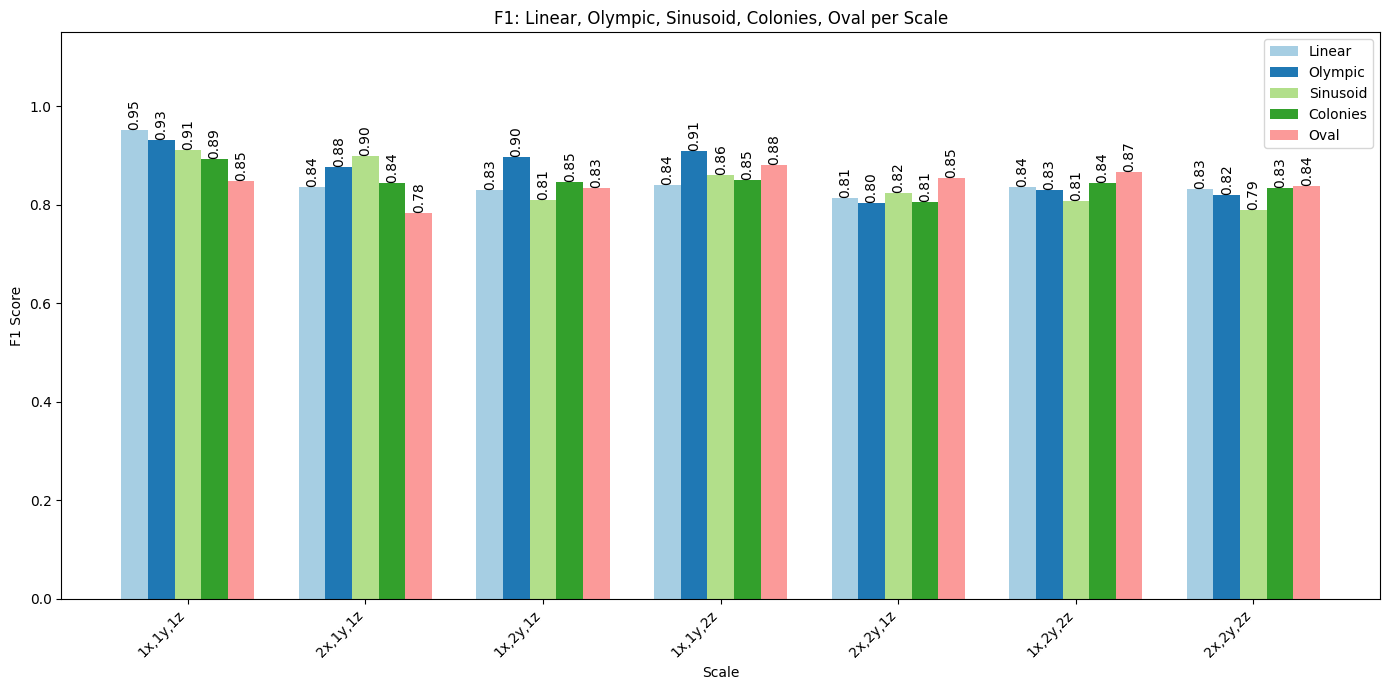

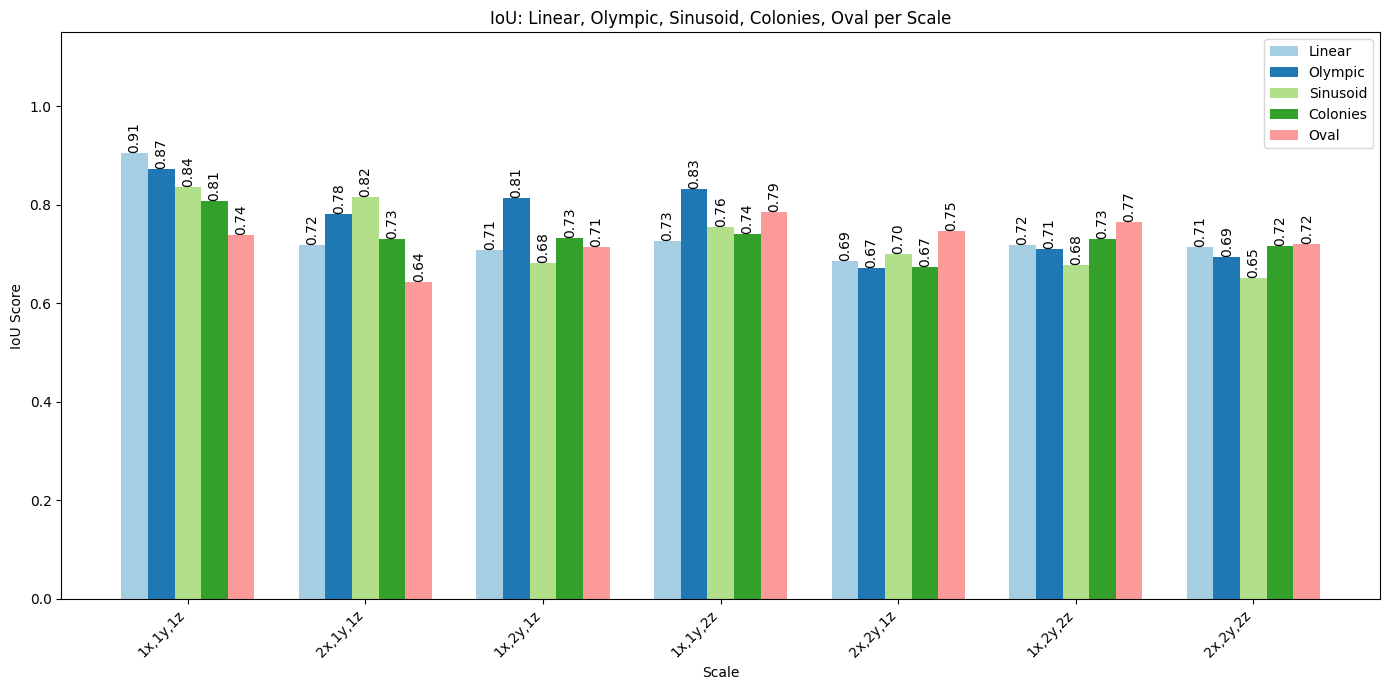

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Data (five patterns: Linear, Olympic, Sinusoid, Colonies, Oval)
data_str = """Scale	Linear F1	Linear IoU	Olympic F1	Olympic IoU	Sinusoid F1	Sinusoid IoU	Colonies F1	Colonies IoU	Oval F1	Oval IoU
1x,1y,1z	0.951	0.906	0.932	0.873	0.911	0.837	0.893	0.807	0.849	0.738
2x,1y,1z	0.837	0.719	0.877	0.782	0.899	0.816	0.844	0.730	0.784	0.644
1x,2y,1z	0.829	0.708	0.897	0.813	0.810	0.681	0.846	0.733	0.834	0.715
1x,1y,2z	0.841	0.726	0.909	0.833	0.861	0.755	0.851	0.740	0.880	0.785
2x,2y,1z	0.814	0.686	0.804	0.672	0.824	0.701	0.805	0.673	0.855	0.747
1x,2y,2z	0.836	0.719	0.830	0.710	0.807	0.677	0.845	0.731	0.867	0.765
2x,2y,2z	0.833	0.714	0.819	0.694	0.789	0.651	0.834	0.716	0.838	0.721"""

lines = data_str.strip().split("\n")
headers = lines[0].split("\t")
rows = []
for line in lines[1:]:
    parts = line.split("\t")
    row = {h: (float(v) if h != "Scale" else v) for h, v in zip(headers, parts)}
    rows.append(row)

patterns = ['Linear', 'Olympic', 'Sinusoid', 'Colonies', 'Oval']
colors = {'Linear': '#a6cee3', 'Olympic': '#1f78b4', 'Sinusoid': '#b2df8a', 'Colonies': '#33a02c', 'Oval': '#fb9a99'}
scales = [r['Scale'] for r in rows]
n_scales = len(scales)

def make_html_table(rows, patterns, metric):
    h = '<table border="1" style="border-collapse:collapse"><tr><th>Scale</th>' + ''.join(f'<th>{p}</th>' for p in patterns) + '</tr>'
    for r in rows:
        h += '<tr><td>' + r['Scale'] + '</td>' + ''.join(f'<td>{r[f"{p} {metric}"]:.3f}</td>' for p in patterns) + '</tr>'
    return h + '</table>'

print("F1 table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'F1')))
print("\nIoU table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'IoU')))

x = np.arange(n_scales)
width = 0.15

# Function to adjust color saturation
def adjust_saturation(hex_color, saturation_factor):
    """Adjust saturation of a hex color. saturation_factor: 1.0 = original, >1.0 = more saturated, <1.0 = less saturated"""
    import matplotlib.colors as mcolors
    rgb = mcolors.hex2color(hex_color)
    # Convert RGB to HSV
    hsv = mcolors.rgb_to_hsv(rgb)
    # Adjust saturation
    hsv[1] = min(1.0, hsv[1] * saturation_factor)
    # Convert back to RGB and then to hex
    rgb_new = mcolors.hsv_to_rgb(hsv)
    return mcolors.rgb2hex(rgb_new)

# Create color dictionaries with different saturation for F1 and IoU
colors_f1 = {p: adjust_saturation(colors[p], 1.3) for p in patterns}  # More saturated for F1
colors_iou = {p: adjust_saturation(colors[p], 0.7) for p in patterns}  # Less saturated for IoU

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 7))

# F1 plot (left)
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} F1'] for r in rows])
    bars = ax1.bar(x + offset, vals, width, label=p, color=colors_f1[p])
    ax1.bar_label(bars, labels=[f'{v:.2f}' for v in vals], rotation=90, fontsize=10)
ax1.set_xlabel('Scale')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1: Linear, Olympic, Sinusoid, Colonies, Oval per Scale')
ax1.set_xticks(x)
ax1.set_xticklabels(scales, rotation=45, ha='right')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1.15)

# IoU plot (right)
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} IoU'] for r in rows])
    bars = ax2.bar(x + offset, vals, width, label=p, color=colors_iou[p])
    ax2.bar_label(bars, labels=[f'{v:.2f}' for v in vals], rotation=90, fontsize=10)
ax2.set_xlabel('Scale')
ax2.set_ylabel('IoU Score')
ax2.set_title('IoU: Linear, Olympic, Sinusoid, Colonies, Oval per Scale')
ax2.set_xticks(x)
ax2.set_xticklabels(scales, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

F1 table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.951,0.932,0.911,0.893,0.849
"2x,1y,1z",0.837,0.877,0.899,0.844,0.784
"1x,2y,1z",0.829,0.897,0.810,0.846,0.834
"1x,1y,2z",0.841,0.909,0.861,0.851,0.880
"2x,2y,1z",0.814,0.804,0.824,0.805,0.855
"1x,2y,2z",0.836,0.830,0.807,0.845,0.867
"2x,2y,2z",0.833,0.819,0.789,0.834,0.838



IoU table (compare all five patterns per Scale):


Scale,Linear,Olympic,Sinusoid,Colonies,Oval
"1x,1y,1z",0.906,0.873,0.837,0.807,0.738
"2x,1y,1z",0.719,0.782,0.816,0.730,0.644
"1x,2y,1z",0.708,0.813,0.681,0.733,0.715
"1x,1y,2z",0.726,0.833,0.755,0.740,0.785
"2x,2y,1z",0.686,0.672,0.701,0.673,0.747
"1x,2y,2z",0.719,0.710,0.677,0.731,0.765
"2x,2y,2z",0.714,0.694,0.651,0.716,0.721


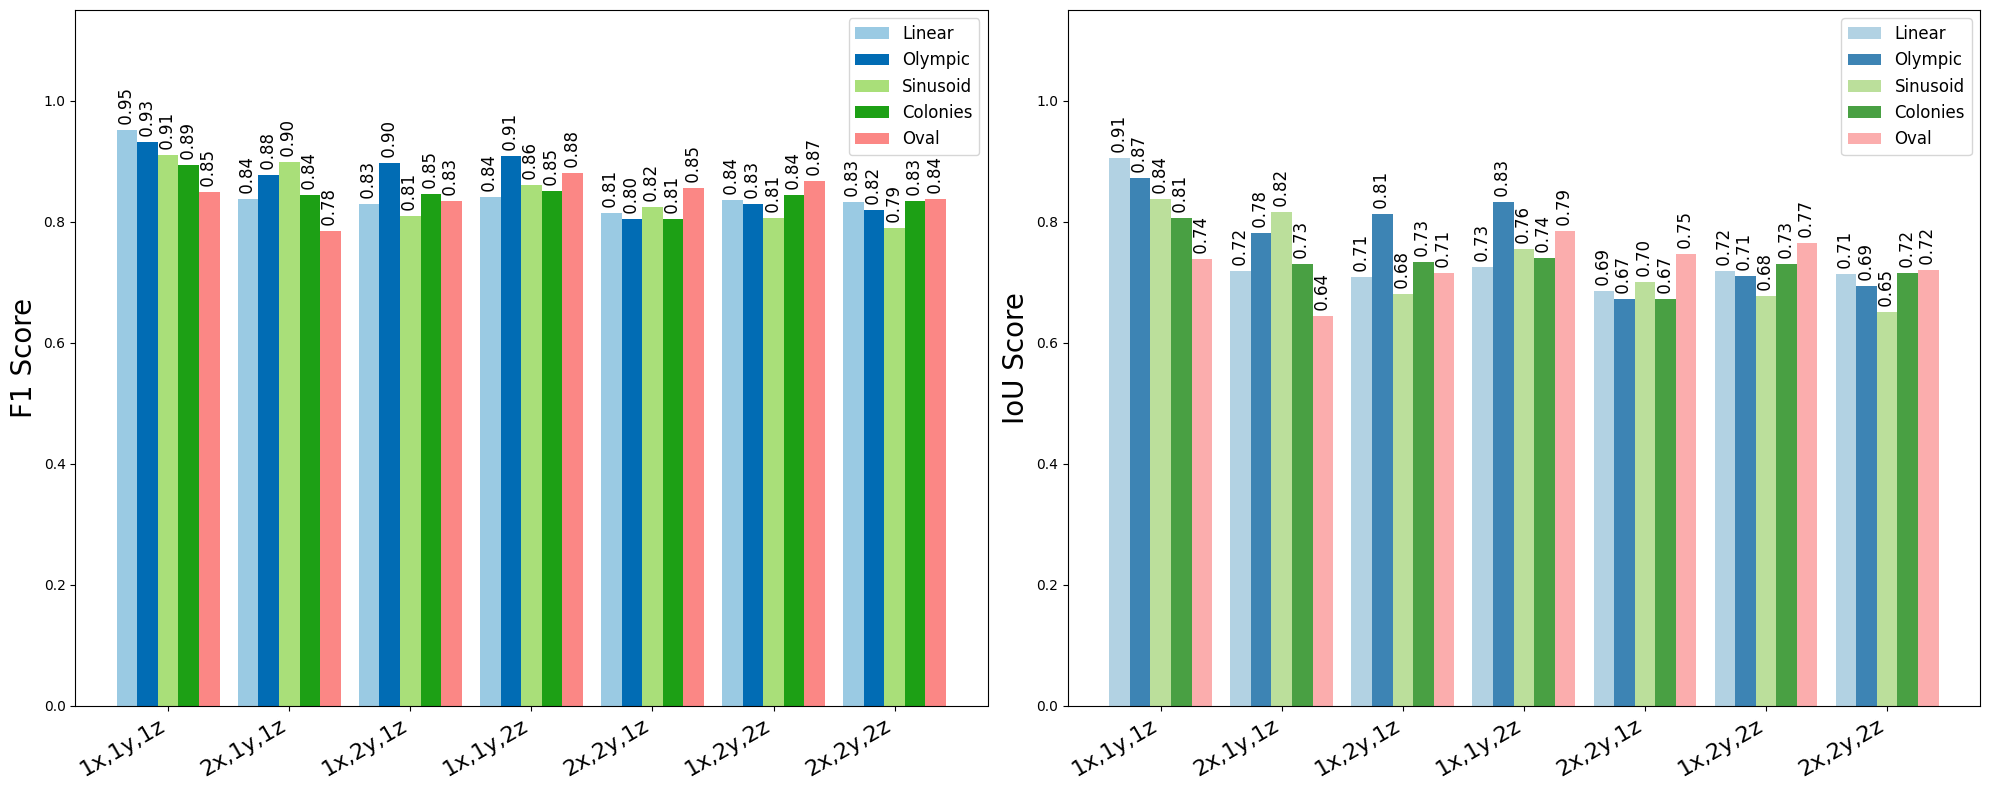

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Data (five patterns: Linear, Olympic, Sinusoid, Colonies, Oval)
data_str = """Scale	Linear F1	Linear IoU	Olympic F1	Olympic IoU	Sinusoid F1	Sinusoid IoU	Colonies F1	Colonies IoU	Oval F1	Oval IoU
1x,1y,1z	0.951	0.906	0.932	0.873	0.911	0.837	0.893	0.807	0.849	0.738
2x,1y,1z	0.837	0.719	0.877	0.782	0.899	0.816	0.844	0.730	0.784	0.644
1x,2y,1z	0.829	0.708	0.897	0.813	0.810	0.681	0.846	0.733	0.834	0.715
1x,1y,2z	0.841	0.726	0.909	0.833	0.861	0.755	0.851	0.740	0.880	0.785
2x,2y,1z	0.814	0.686	0.804	0.672	0.824	0.701	0.805	0.673	0.855	0.747
1x,2y,2z	0.836	0.719	0.830	0.710	0.807	0.677	0.845	0.731	0.867	0.765
2x,2y,2z	0.833	0.714	0.819	0.694	0.789	0.651	0.834	0.716	0.838	0.721"""

lines = data_str.strip().split("\n")
headers = lines[0].split("\t")
rows = []
for line in lines[1:]:
    parts = line.split("\t")
    row = {h: (float(v) if h != "Scale" else v) for h, v in zip(headers, parts)}
    rows.append(row)

patterns = ['Linear', 'Olympic', 'Sinusoid', 'Colonies', 'Oval']
colors = {'Linear': '#a6cee3', 'Olympic': '#1f78b4', 'Sinusoid': '#b2df8a', 'Colonies': '#33a02c', 'Oval': '#fb9a99'}
scales = [r['Scale'] for r in rows]
n_scales = len(scales)

def make_html_table(rows, patterns, metric):
    h = '<table border="1" style="border-collapse:collapse"><tr><th>Scale</th>' + ''.join(f'<th>{p}</th>' for p in patterns) + '</tr>'
    for r in rows:
        h += '<tr><td>' + r['Scale'] + '</td>' + ''.join(f'<td>{r[f"{p} {metric}"]:.3f}</td>' for p in patterns) + '</tr>'
    return h + '</table>'

print("F1 table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'F1')))
print("\nIoU table (compare all five patterns per Scale):")
display(HTML(make_html_table(rows, patterns, 'IoU')))

x = np.arange(n_scales)
width = 0.17

# Function to adjust color saturation
def adjust_saturation(hex_color, saturation_factor):
    """Adjust saturation of a hex color. saturation_factor: 1.0 = original, >1.0 = more saturated, <1.0 = less saturated"""
    import matplotlib.colors as mcolors
    rgb = mcolors.hex2color(hex_color)
    # Convert RGB to HSV
    hsv = mcolors.rgb_to_hsv(rgb)
    # Adjust saturation
    hsv[1] = min(1.0, hsv[1] * saturation_factor)
    # Convert back to RGB and then to hex
    rgb_new = mcolors.hsv_to_rgb(hsv)
    return mcolors.rgb2hex(rgb_new)

# Create color dictionaries with different saturation for F1 and IoU
colors_f1 = {p: adjust_saturation(colors[p], 1.2) for p in patterns}  # More saturated for F1
colors_iou = {p: adjust_saturation(colors[p], 0.8) for p in patterns}  # Less saturated for IoU

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# F1 plot (left)
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} F1'] for r in rows])
    bars = ax1.bar(x + offset, vals, width, label=p, color=colors_f1[p])
    ax1.bar_label(bars, labels=[f' {v:.2f}' for v in vals], rotation=90, fontsize=12)
ax1.set_ylabel('F1 Score',fontsize=20)
ax1.set_xticks(x)
ax1.set_xticklabels(scales, rotation=30, ha='right',fontsize=16)
ax1.legend(loc='upper right',fontsize=12)
ax1.set_ylim(0, 1.15)

# IoU plot (right)
for i, p in enumerate(patterns):
    offset = (i - 2) * width
    vals = np.array([r[f'{p} IoU'] for r in rows])
    bars = ax2.bar(x + offset, vals, width, label=p, color=colors_iou[p])
    ax2.bar_label(bars, labels=[f' {v:.2f}' for v in vals], rotation=90, fontsize=12)
ax2.set_ylabel('IoU Score',fontsize=20)
ax2.set_xticks(x)
ax2.set_xticklabels(scales, rotation=30, ha='right',fontsize=16)
ax2.legend(loc='upper right',fontsize=12)
ax2.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()